# Machine Learning Final Project : Nutrient Regression
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

### Import Libraries

In [11]:
%reset -f

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import gc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

In [13]:
# Utility function to build and compile LSTM model
def make_lstm_model(window_size, feature_count, output_count, units_1, units_2, dropout_1, dropout_2, l2_reg, learning_rate):
    model = Sequential()
    model.add(Input(shape=(window_size, feature_count)))
    model.add(LSTM(units=units_1, return_sequences=True))
    model.add(Dropout(dropout_1))
    model.add(BatchNormalization())
    model.add(LSTM(units=units_2))
    model.add(Dropout(dropout_2))
    model.add(BatchNormalization())
    model.add(Dense(output_count, kernel_regularizer=l2_reg, activation='sigmoid')) # Sigmoid for classification
    adam_opt = Adam(learning_rate=learning_rate)
    model.compile(optimizer=adam_opt, loss='binary_crossentropy')
    return model

### Load Cleaned Dataset

In [14]:
# Load datatypes for final_food_data
with open('final_food_data_dtypes.json', 'r') as f:
    final_food_data_dtypes = json.load(f)

# Load processed dataset
food_data = pd.read_csv('final_food_data.csv', dtype=final_food_data_dtypes)


# Select all one-hot ingredient columns as targets
ingredient_oh_cols = [col for col in food_data.columns if col.startswith('ingredient_oh_')]
print(f'Ingredient one-hot columns: {ingredient_oh_cols[:10]} ... total: {len(ingredient_oh_cols)}')

# Drop ingredient one-hot columns with >99% zeros
ingredient_oh_cols = [
    col for col in ingredient_oh_cols
    if (food_data[col] == 0).mean() <= 0.99
]
print(f'Filtered ingredient one-hot columns: {ingredient_oh_cols[:10]} ... total: {len(ingredient_oh_cols)}')

# Select all nutrient amount columns (exclude logs and package weight)
nutrient_candidates = [col for col in food_data.columns if 'amount' in col and not col.endswith('_log') and not col == 'package_weight_amount']
print('Zero percentage for each nutrient candidate:')
nutrient_cols = []
for col in nutrient_candidates:
    zero_pct = (food_data[col] == 0).mean() * 100
    print(f'{col}: {zero_pct:.2f}% zero')
    if zero_pct <= 90:
        nutrient_cols.append(col)

# Drop failed nutrient candidates from feature columns
failed_nutrient_cols = [col for col in nutrient_candidates if col not in nutrient_cols]

Ingredient one-hot columns: ['ingredient_oh_salt', 'ingredient_oh_sugar', 'ingredient_oh_water', 'ingredient_oh_citricAcid', 'ingredient_oh_cornSyrup', 'ingredient_oh_naturalFlavor', 'ingredient_oh_soyLecithin', 'ingredient_oh_seaSalt', 'ingredient_oh_natural', 'ingredient_oh_dextrose'] ... total: 500
Filtered ingredient one-hot columns: ['ingredient_oh_salt', 'ingredient_oh_sugar', 'ingredient_oh_water', 'ingredient_oh_citricAcid', 'ingredient_oh_cornSyrup', 'ingredient_oh_naturalFlavor', 'ingredient_oh_soyLecithin', 'ingredient_oh_seaSalt', 'ingredient_oh_natural', 'ingredient_oh_dextrose'] ... total: 167
Zero percentage for each nutrient candidate:
Acetic acid amount: 100.00% zero
Alanine amount: 99.98% zero
Alcohol, ethyl amount: 100.00% zero
Arginine amount: 99.98% zero
Ash amount: 99.82% zero
Aspartic acid amount: 99.98% zero
Beta-glucans amount: 100.00% zero
Biotin amount: 99.80% zero
Caffeine amount: 99.96% zero
Calcium, Ca amount: 44.51% zero
Carbohydrate, by difference amount

In [15]:
# Prepare input features (exclude ingredient one-hot columns)
exclude_cols = set(ingredient_oh_cols)
feature_cols = [col for col in food_data.columns if col not in exclude_cols and col not in set(failed_nutrient_cols)]

# Memory cleanup after data loading
def memory_cleanup(data):
    for var in data:
        if var in locals():
            del globals()[var]
    gc.collect()
    
memory_cleanup(['final_food_data_dtypes', 'f', 'exclude_cols'])

In [16]:
# Drop highly correlated features
correlation_threshold = 0.95
corr_matrix = food_data[feature_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > correlation_threshold)]
print(f'Dropping {len(to_drop)} highly correlated features: {to_drop[:10]} ...')
feature_cols = [col for col in feature_cols if col not in to_drop]
memory_cleanup(['corr_matrix', 'upper_tri', 'to_drop'])

Dropping 2 highly correlated features: ['Iron, Fe amount_log', 'brand_encoded'] ...


## Step 1: Train/Test Split

In [17]:
# Batch generator for memory-efficient training
def batch_generator(data, feature_cols, ingredient_oh_cols, window_size=3, batch_size=128):
    num_rows = len(data)
    while True:
        for start in range(window_size, num_rows, batch_size):
            end = min(start + batch_size, num_rows)
            X_batch = []
            y_batch = []
            for i in range(start, end):
                X_window = data.iloc[i-window_size:i][feature_cols].values
                y_row = data.iloc[i][ingredient_oh_cols].values
                X_batch.append(X_window)
                y_batch.append(y_row)
            yield np.array(X_batch), np.array(y_batch)

In [18]:
# Set window size and batch size
window_size = 3
batch_size = 128

# Calculate split index for train/test
num_rows = len(food_data)
split_idx = int((num_rows - window_size) * 0.8)
print(f'[Split] Total rows: {num_rows}, Train rows: {split_idx + window_size}, Test rows: {num_rows - split_idx}')

# Define train and test generators
train_gen = batch_generator(
    food_data.iloc[:split_idx + window_size],
    feature_cols,
    ingredient_oh_cols,
    window_size=window_size,
    batch_size=batch_size
)
test_gen = batch_generator(
    food_data.iloc[split_idx:],
    feature_cols,
    ingredient_oh_cols,
    window_size=window_size,
    batch_size=batch_size
)

# Calculate steps per epoch
train_steps = (split_idx) // batch_size
test_steps = (num_rows - window_size - split_idx) // batch_size
print(f'[Steps] Train steps per epoch: {train_steps}, Test steps: {test_steps}')

[Split] Total rows: 1977398, Train rows: 1581919, Test rows: 395482
[Steps] Train steps per epoch: 12358, Test steps: 3089


## Step 2: Build the Model

In [19]:
# Build the LSTM model for multi-output regression with L2 regularization using best hyperparameters from KerasTuner
l2_reg = regularizers.l2(0.001)
units_1 = 32
units_2 = 96
dropout_1 = 0.2
dropout_2 = 0.2
learning_rate = 0.001
print(f'[Model] Building LSTM model with input shape ({window_size}, {len(feature_cols)}) and output size {len(ingredient_oh_cols)}')
model = make_lstm_model(window_size, len(feature_cols), len(ingredient_oh_cols), units_1, units_2, dropout_1, dropout_2, l2_reg, learning_rate)

[Model] Building LSTM model with input shape (3, 473) and output size 167


## Step 3: Train the Model

In [20]:
# Fit the model using the batch generator
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print(f'[Training] Starting model.fit for up to 20 epochs, batch size {batch_size}, train steps {train_steps}, validation steps {test_steps}')
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=20,
    validation_data=test_gen,
    validation_steps=test_steps,
    callbacks=[early_stop]
)

[Training] Starting model.fit for up to 20 epochs, batch size 128, train steps 12358, validation steps 3089
Epoch 1/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1867s 151ms/step - loss: 0.1470 - val_loss: 0.1337
Epoch 2/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1856s 150ms/step - loss: 0.1291 - val_loss: 0.1326
Epoch 3/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1837s 149ms/step - loss: 0.1277 - val_loss: 0.1317
Epoch 4/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1775s 144ms/step - loss: 0.1273 - val_loss: 0.1315
Epoch 5/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1847s 150ms/step - loss: 0.1272 - val_loss: 0.1315
Epoch 6/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1852s 150ms/step - loss: 0.1273 - val_loss: 0.1315
Epoch 7/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2294s 186ms/step - loss: 0.1273 - val_loss: 0.1315


In [21]:
# Collect predictions and true values from test generator for classification calculation
y_true = []
y_pred = []
for batch_num in range(test_steps):
    X_batch, y_batch = next(test_gen)
    preds = model.predict(X_batch)
    y_true.append(y_batch)
    y_pred.append(preds)
    percent_complete = int(100 * (batch_num + 1) / test_steps)
    print(f'\n[Prediction] {percent_complete}%', end='\r')
    gc.collect()
y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━

In [22]:
# Evaluate accuracy, recall, precision, and f1 for each ingredient using sklearn metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def get_classification_metrics(y_true, y_pred):
    accuracies = []
    recalls = []
    precisions = []
    f1s = []
    for i in range(y_true.shape[1]):
        y_true_bin = (y_true[:, i] >= 0.5).astype(int)
        y_pred_bin = (y_pred[:, i] >= 0.5).astype(int)
        accuracy = accuracy_score(y_true_bin, y_pred_bin)
        recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        accuracies.append(accuracy)
        recalls.append(recall)
        precisions.append(precision)
        f1s.append(f1)
    return accuracies, f1s, recalls, precisions

accuracies, f1s, recalls, precisions = get_classification_metrics(y_true, y_pred)
for i in range(len(ingredient_oh_cols)):
    print(f'Ingredient: {ingredient_oh_cols[i]} - Accuracy: {accuracies[i]:.4f}, Recall: {recalls[i]:.4f}, Precision: {precisions[i]:.4f}, F1: {f1s[i]:.4f}')

Ingredient: ingredient_oh_salt - Accuracy: 0.5377, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_sugar - Accuracy: 0.6755, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_water - Accuracy: 0.6790, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_citricAcid - Accuracy: 0.8165, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_cornSyrup - Accuracy: 0.8937, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_naturalFlavor - Accuracy: 0.8598, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_soyLecithin - Accuracy: 0.8987, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_seaSalt - Accuracy: 0.8906, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_natural - Accuracy: 0.8942, Recall: 0.0000, Precision: 0.0000, F1: 0.0000
Ingredient: ingredient_oh_dextrose - Accuracy: 0.9127, Recall: 0.0000, Precision: 0.0000, F1

## Step 4: Evaluate the Model

In [23]:
# Print summary statistics for classification metrics
print('Classification Metrics Summary:')
print(f'Mean Accuracy: {np.mean(accuracies):.4f}')
print(f'Median Accuracy: {np.median(accuracies):.4f}')
print(f'Mean Recall: {np.mean(recalls):.4f}')
print(f'Median Recall: {np.median(recalls):.4f}')
print(f'Mean Precision: {np.mean(precisions):.4f}')
print(f'Median Precision: {np.median(precisions):.4f}')
print(f'Mean F1: {np.mean(f1s):.4f}')
print(f'Median F1: {np.median(f1s):.4f}')

Classification Metrics Summary:
Mean Accuracy: 0.9655
Median Accuracy: 0.9803
Mean Recall: 0.0000
Median Recall: 0.0000
Mean Precision: 0.0000
Median Precision: 0.0000
Mean F1: 0.0000
Median F1: 0.0000


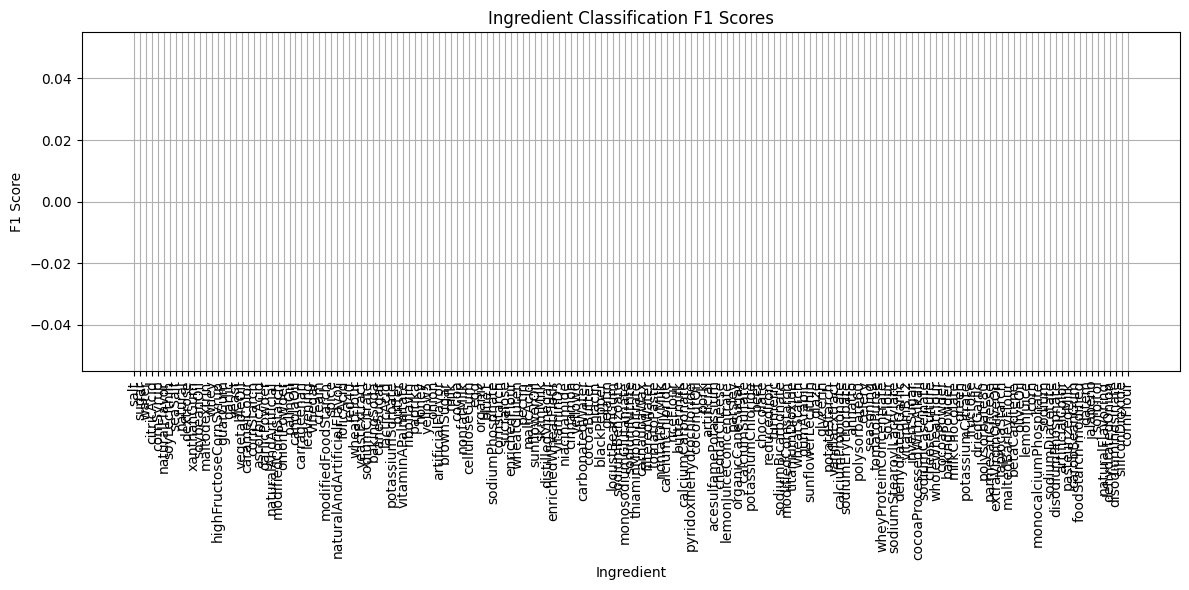

In [24]:
# Visualize ingredient classification: bar plot of mean F1 scores
plt.figure(figsize=(12, 6))
plt.bar(range(len(ingredient_oh_cols)), f1s, tick_label=[col.replace('ingredient_oh_', '') for col in ingredient_oh_cols])
plt.xlabel('Ingredient')
plt.ylabel('F1 Score')
plt.title('Ingredient Classification F1 Scores')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()